# $visit_n - visit_1 \rightarrow fatigue_n - fatigue_1$
$\Delta visit \rightarrow \Delta fatigue$ \
Finds difference from **first** visit to current visit **using weekly DMOs**

In [1]:
from src.patient_data_dispatcher import PatientDataDispatcher
from src.model import ModelConfig
from src.core.enums import MileStone, PatientDataType, DataFrequency
from src.core.normaliser import Normaliser
from sklearn.preprocessing import MinMaxScaler
from src.train.train_regression_xv import LSTMRegressionXV
from src.core.data_transforms import Transform


import torch

/home/gwilym-rutherford/Documents/Year 3 Tuos/dissertation/Workspace/Experiment 1/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
K_FOLDS = 5
N_VISITS = 4

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
from torch.nn import HuberLoss, CrossEntropyLoss, MSELoss
from torch.optim import Adam

config = ModelConfig(
    name="lstm_regression",
    model_type="LSTM",
    input_size=25,
    hidden_size=128,
    num_layers=1,
    output_size=1,
    batch_size=16,
    epochs=50,
    optimiser=Adam,
    loss_fn=MSELoss(),
    learning_rate=5e-4,
)

config.notes = "None"

In [5]:
dmo_features = [
    "wb_all_sum",
    "walkdur_all_sum",
    "wbsteps_all_sum",
    "wbdur_all_avg",
    "wbdur_all_p90",
    "wbdur_all_var",
    "cadence_all_avg",
    "strdur_all_avg",
    "cadence_all_var",
    "strdur_all_var",
    "ws_1030_avg",
    "strlen_1030_avg",
    "wb_10_sum",
    "ws_10_p90",
    "wb_30_sum",
    "ws_30_avg",
    "strlen_30_avg",
    "cadence_30_avg",
    "strdur_30_avg",
    "ws_30_p90",
    "cadence_30_p90",
    "ws_30_var",
    "strlen_30_var",
    "wb_60_sum",
    "total_worn_h",
]

In [6]:
pdd = PatientDataDispatcher(
    "config/config.yaml",
    dmo_features,
    MileStone.ALL,
    data_frequency=DataFrequency.DAILY,
)
ids = list(set(pdd.metadata["Local.Participant"].to_list()))
dmo_data, dmo_labels = pdd.get_patient_data(PatientDataType.MILESTONE, ids=ids)

In [7]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# perform impute on a visit by visit basis, as some visits are completely missing
imputer = IterativeImputer(missing_values=-1, tol=1e-2, keep_empty_features=True)
patients, visits, features, days = dmo_data.shape

for p in range(patients):
    for v in range(visits):
        visit_data = dmo_data[p, v]

        if (visit_data == -1).all():
            continue

        dmo_data[p, v] = torch.from_numpy(imputer.fit_transform(visit_data)).to(dtype=torch.float64)

/home/gwilym-rutherford/Documents/Year 3 Tuos/dissertation/Workspace/Experiment 1/.venv/lib/python3.13/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


In [8]:
dmo_data, dmo_labels = Transform.get_patient_visits(dmo_data, dmo_labels, n_visits=N_VISITS)

In [9]:
# remove patients that don't have a full dataset
patient_indexs = []
patient, visit, day, features = dmo_data.shape
for p in range(patient):
    all_visits = True
    for v in range(visit):
        data = dmo_data[p, v]
        label = dmo_labels[p, v]
        if (data == -1.0).any() or label == -1.0:
            all_visits = False

    if all_visits:
        patient_indexs.append(p)

dmo_data = dmo_data[patient_indexs]
dmo_labels = dmo_labels[patient_indexs]

In [10]:
#dmo_data = dmo_data.mean(axis=2)

In [11]:
print(dmo_data.shape)

torch.Size([428, 4, 7, 25])


In [12]:
# Min max normalise the labels globally

label_normaliser = Normaliser(MinMaxScaler())
dmo_labels = label_normaliser.scaler_fit_transform(dmo_labels)

In [13]:
def format_input_data_delta_visit(input_data):
    if len(input_data.shape) < 4:
            input_data = input_data.unsqueeze(dim=2)

    patients, visits, days, features = input_data.shape

    delta_visits = torch.zeros(patients, visits - 1, days, features)
    for patient in range(patients):
        reference_visit = input_data[patient, 0]
        for visit in range(visits - 1):
            updated_visit = input_data[patient, visit + 1] - reference_visit
            delta_visits[patient, visit] = updated_visit 

    return delta_visits

def format_label_data_delta_visit(label_data):
    patients, visits, labels = label_data.shape
    
    delta_labels = torch.zeros(patients, (visits - 1), labels)
    for patient in range(patients):
        reference_label = label_data[patient, 0]
        delta_visits = label_data[patient, 1:] - reference_label

        delta_labels[patient] = delta_visits

    return delta_labels
    # return delta_labels


In [14]:
dmo_data = format_input_data_delta_visit(dmo_data)
dmo_labels = format_label_data_delta_visit(dmo_labels)

In [15]:
dmo_data = dmo_data.mean(axis=2)

In [16]:
dmo_data.shape

torch.Size([428, 3, 25])

In [17]:
dmo_labels.shape

torch.Size([428, 3, 1])

In [18]:
xv_trainer = LSTMRegressionXV(dmo_data, dmo_labels, config, device, k=K_FOLDS)
prediction, actual = xv_trainer.train_cross_validation()

Testing loss: 0.04374481923878193
<class 'list'>
[tensor([[-0.0724],
        [-0.0960],
        [-0.1348]]), tensor([[ 0.0211],
        [-0.1164],
        [ 0.0824]]), tensor([[0.0119],
        [0.0707],
        [0.0002]]), tensor([[0.0116],
        [0.0487],
        [0.1170]]), tensor([[-0.0138],
        [-0.0307],
        [-0.0390]]), tensor([[-0.0557],
        [ 0.1000],
        [-0.1366]]), tensor([[-0.0049],
        [ 0.0047],
        [ 0.2139]]), tensor([[0.0090],
        [0.0121],
        [0.0847]]), tensor([[-0.0040],
        [-0.0310],
        [-0.0063]]), tensor([[-0.0135],
        [-0.0480],
        [ 0.1498]]), tensor([[-0.0203],
        [ 0.3610],
        [ 0.6204]]), tensor([[ 0.0126],
        [-0.0401],
        [ 0.0386]]), tensor([[0.1032],
        [0.3625],
        [0.3288]]), tensor([[ 0.0407],
        [-0.0575],
        [-0.2030]]), tensor([[ 0.0176],
        [ 0.0165],
        [-0.0182]]), tensor([[0.0625],
        [0.0871],
        [0.0382]]), tensor([[-0.3079],
  

In [19]:
prediction

[tensor([-7.2417e-02, -9.6040e-02, -1.3483e-01,  2.1094e-02, -1.1644e-01,
          8.2389e-02,  1.1896e-02,  7.0672e-02,  1.6778e-04,  1.1622e-02,
          4.8676e-02,  1.1703e-01, -1.3794e-02, -3.0688e-02, -3.8982e-02,
         -5.5701e-02,  9.9960e-02, -1.3662e-01, -4.8631e-03,  4.6634e-03,
          2.1389e-01,  8.9667e-03,  1.2108e-02,  8.4676e-02, -4.0008e-03,
         -3.0985e-02, -6.2631e-03, -1.3464e-02, -4.7983e-02,  1.4976e-01,
         -2.0345e-02,  3.6099e-01,  6.2038e-01,  1.2634e-02, -4.0054e-02,
          3.8641e-02,  1.0315e-01,  3.6249e-01,  3.2885e-01,  4.0723e-02,
         -5.7484e-02, -2.0304e-01,  1.7636e-02,  1.6509e-02, -1.8248e-02,
          6.2483e-02,  8.7105e-02,  3.8208e-02, -3.0789e-01, -4.6066e-01,
         -1.9726e-01,  1.2379e-01,  1.8618e-01,  3.1317e-01, -2.4141e-01,
         -3.8651e-01, -3.0764e-01, -9.2853e-03,  6.4082e-03, -8.0555e-03,
          3.8509e-03, -2.1679e-04, -5.2004e-02,  5.3228e-02,  1.7620e-02,
          8.4776e-02,  2.3506e-02, -4.

In [20]:
prediction = torch.concatenate(prediction).flatten().reshape(dmo_labels.shape)
prediction = label_normaliser.scaler_inverse_labels(prediction).flatten()
prediction.shape

torch.Size([1284])

In [21]:
actual = torch.concatenate(actual).flatten().reshape(dmo_labels.shape)
actual = label_normaliser.scaler_inverse_labels(actual).flatten()
actual.shape

torch.Size([1284])

In [22]:
print(xv_trainer.R2_values)

[-0.5970745086669922, -0.34287548065185547, -0.8165003061294556, -0.4162026643753052, -0.5340566635131836]


All metrics: {'accuracy': 0.017133956386292833, 'Mean Squared Error': 53.22187042236328, 'Mean Absolute Error': 5.539007186889648, 'R^2': -0.508177965016757}


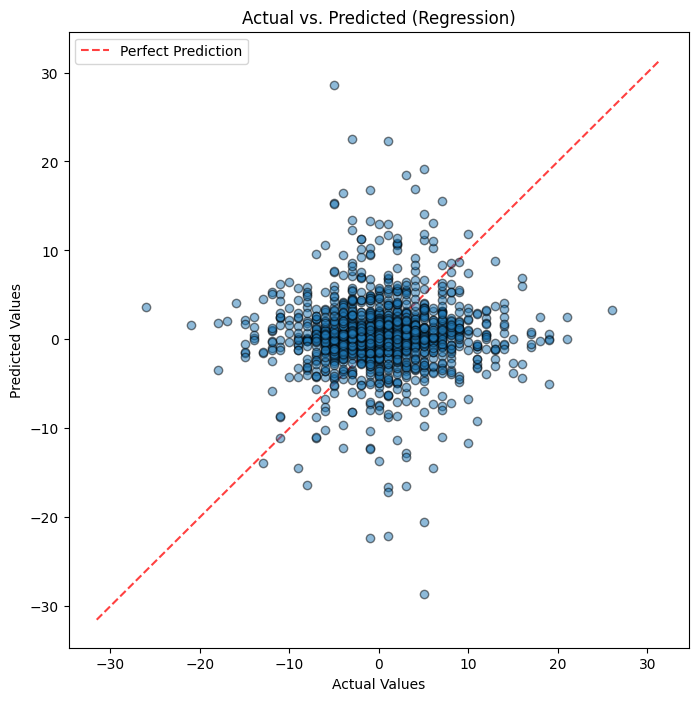

In [23]:
from src.evaluation import Evaluation

evaluation = Evaluation(prediction, actual)
print(f"All metrics: {evaluation.compute_all_metrics()}")
evaluation.evaluation_plot().show()
